In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

import func

In [3]:
def cov(X):
    X = X.reshape(len(X), -1)
    _, C = func.normalize(X)
    return C

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train_small = func.downsize_mnist(x_train)
x_test_small = func.downsize_mnist(x_test)

In [5]:
eig_train = np.linalg.eigvalsh(cov(x_train))
eig_test = np.linalg.eigvalsh(cov(x_test))
eig_train_small = np.linalg.eigvalsh(cov(x_train_small))
eig_test_small = np.linalg.eigvalsh(cov(x_test_small))

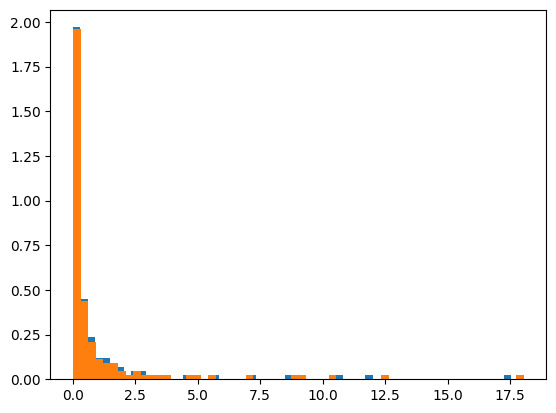

In [7]:
plt.hist(eig_train_small, bins=60, density=True)
plt.hist(eig_test_small, bins=60, density=True)
plt.savefig('spectral.pdf')

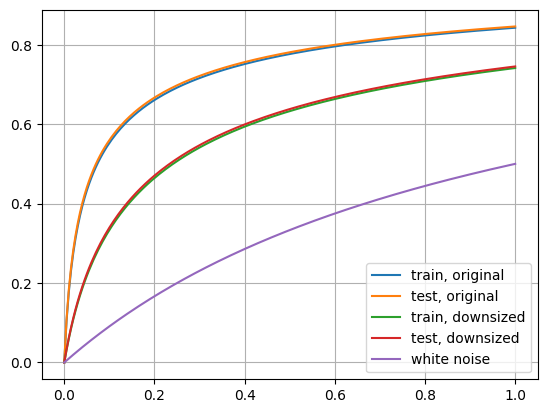

In [8]:
ls = np.linspace(0, 1, 201)
ms_train = func.m_C(eig_train, ls)
ms_test = func.m_C(eig_test, ls)
ms_train_small = func.m_C(eig_train_small, ls)
ms_test_small = func.m_C(eig_test_small, ls)
plt.plot(ls, ms_train, label='train, original')
plt.plot(ls, ms_test, label='test, original')
plt.plot(ls, ms_train_small, label='train, downsized')
plt.plot(ls, ms_test_small, label='test, downsized')
plt.plot(ls, ls/(ls+1), label='white noise')
plt.legend()
plt.grid()
plt.show()

In [9]:
np.savetxt('eig_test_small.csv', eig_test_small, delimiter=',')